In [1]:
# !pip install torch

In [2]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [3]:
x_2 = inputs[1] #A
d_in = inputs.shape[1] #B
d_out = 2

In [4]:
torch.manual_seed(123)
#Basically (d_in,d_out) = (3,2)
W_query = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)

In [5]:
print(W_query)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])


In [6]:
print(W_key)

Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])


In [7]:
print(W_value)

Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


In [8]:
#This is just for the example
#Journey ke liye
query_2 = x_2 @ W_query 
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value
print(query_2)#This is the exact answer which i have written in the Notes

tensor([0.4306, 1.4551])


In [9]:
#This is the main calculation
key = inputs @ W_key
value = inputs @ W_value
query = inputs @ W_query
#This easily depicts the dimensions of the Key, Queries, Values
print(key)
print("Shape of the Key: ",key.shape)
print(value)
print("Shape of the Value: ",value.shape)
print(query)
print("Shape of the Query",query.shape)

tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]])
Shape of the Key:  torch.Size([6, 2])
tensor([[0.1855, 0.8812],
        [0.3951, 1.0037],
        [0.3879, 0.9831],
        [0.2393, 0.5493],
        [0.1492, 0.3346],
        [0.3221, 0.7863]])
Shape of the Value:  torch.Size([6, 2])
tensor([[0.2309, 1.0966],
        [0.4306, 1.4551],
        [0.4300, 1.4343],
        [0.2355, 0.7990],
        [0.2983, 0.6565],
        [0.2568, 1.0533]])
Shape of the Query torch.Size([6, 2])


In [10]:
keys_2 = key[1]
attn_score_22 = query_2.dot(keys_2)

In [11]:
attn_scores_2 = query_2 @ key.T
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [12]:
attn_scores = query @key.T
print(attn_scores)

tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


In [13]:
d_k = key.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**2, dim=-1)
print(attn_weights_2)
print(d_k)

tensor([0.1623, 0.1877, 0.1858, 0.1547, 0.1358, 0.1738])
2


In [14]:
import torch
tensor = torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])
softmax_result = torch.softmax(tensor, dim = -1)
print("Softmax without scaling:", softmax_result)

#Multiplying krdo by 8
scaled_tensor = tensor * 8
softmax_scaled_result = torch.softmax(scaled_tensor, dim = -1)
print("Softmax after scaling(tensor * 8)",softmax_scaled_result)

Softmax without scaling: tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
Softmax after scaling(tensor * 8) tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


In [15]:
import numpy as np

# Function to create variance before and after scaling
def compute_var(dim, num_trials=1000):
    dot_products = []
    scaled_dot_products = []

    for _ in range(num_trials):
        q = np.random.randn(dim)
        k = np.random.randn(dim)

        dot_prod = np.dot(q, k)
        dot_products.append(dot_prod)

        # scale the dot product by sqrt(dim)
        scaled_dot_prod = dot_prod / np.sqrt(dim)
        scaled_dot_products.append(scaled_dot_prod)

    var_before_scaling = np.var(dot_products)
    var_after_scaling = np.var(scaled_dot_products) 

    return var_before_scaling, var_after_scaling

var_before_5, var_after_5 = compute_var(5)
print(f"Variance before scaling (dim=5): {var_before_5:.4f}")
print(f"Variance after scaling  (dim=5): {var_after_5:.4f}")

var_before_20, var_after_20 = compute_var(20)
print(f"Variance before scaling (dim=100): {var_before_20:.4f}")
print(f"Variance after scaling  (dim=20): {var_after_20:.4f}")


Variance before scaling (dim=5): 4.5733
Variance after scaling  (dim=5): 0.9147
Variance before scaling (dim=100): 19.0606
Variance after scaling  (dim=20): 0.9530


In [16]:
import numpy as np

# Function to create variance before and after scaling
def compute_var(dim, num_trials=1000):
    dot_products = []
    scaled_dot_products = []

    for _ in range(num_trials):
        q = np.random.randn(dim)
        k = np.random.randn(dim)

        dot_prod = np.dot(q, k)
        dot_products.append(dot_prod)

        # scale the dot product by sqrt(dim)
        scaled_dot_prod = dot_prod / np.sqrt(dim)
        scaled_dot_products.append(scaled_dot_prod)

    var_before_scaling = np.var(dot_products)
    var_after_scaling = np.var(scaled_dot_products) 

    return var_before_scaling, var_after_scaling

var_before_5, var_after_5 = compute_var(5)
print(f"Variance before scaling (dim=5): {var_before_5:.4f}")
print(f"Variance after scaling  (dim=5): {var_after_5:.4f}")

var_before_100, var_after_100 = compute_var(100)
print(f"Variance before scaling (dim=100): {var_before_100:.4f}")
print(f"Variance after scaling  (dim=20): {var_after_100:.4f}")


Variance before scaling (dim=5): 5.5032
Variance after scaling  (dim=5): 1.1006
Variance before scaling (dim=100): 98.2584
Variance after scaling  (dim=20): 0.9826


In [17]:
 #If we dont use square root the variance will not be close to 1

In [18]:
#Ab hoga Context vector calculate
#Journey ka context vector
context_vec_2 = attn_weights_2 @ value
print(context_vec_2)

tensor([0.2896, 0.7811])


In [19]:
#Implementing a Compact Self Attention
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self,d_in,d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in,d_out))
        self.W_key = nn.Parameter(torch.rand(d_in,d_out))
        self.W_value = nn.Parameter(torch.rand(d_in,d_out))
        
    def forward(self,x):
        keys = x@self.W_key
        queries = x@self.W_query
        values = x@self.W_value

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1] ** 0.5, dim = -1

        )
        context_vec = attn_weights @ values
        return context_vec


In [20]:
import torch
#Creting an instance of class
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in,d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        queries = self.W_query(x)   
        keys    = self.W_key(x)     
        values  = self.W_value(x)   

        attn_scores = torch.matmul(queries, keys.transpose(-2, -1))  
        attn_scores = attn_scores / (keys.shape[-1] ** 0.5)  
        attn_weights = F.softmax(attn_scores, dim=-1)

        # Weighted sum of values
        context_vec = torch.matmul(attn_weights, values)  # (batch, seq_len, d_out)
        return context_vec


In [22]:
#For more optimised approach we have to apply nn.linear in place of
#nn.parameter

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in,d_out)
print(sa_v2(inputs))


tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


In [23]:
queries = sa_v2.W_query(inputs) #A value
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim = 1)
print("Ye rha Attention weights: ",attn_weights)



Ye rha Attention weights:  tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [24]:
#Ex of torch.tril (Lower triangular matrix)
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length,context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [25]:
masked_simple = attn_weights * mask_simple
print(masked_simple)


tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [26]:
#Third step is to normalize as the rows are not becoming equal to one
#Renormalising 

row_sums = masked_simple.sum(dim = 1,keepdim=True)
masked_simple_norm = masked_simple / row_sums
print("Now sum is 1 for the row: \n",masked_simple_norm)

Now sum is 1 for the row: 
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [27]:
print(attn_scores)

tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)


In [28]:
# mask = torch.triu(torch.ones(context_length,context_length),diagonal = 1)
# print(mask)

In [29]:
mask = torch.triu(torch.ones(context_length,context_length),diagonal = 1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked) #formula for exponenial

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [30]:
attn_weights = torch.softmax(masked / keys.shape[-1] ** 0.5, dim = 1)
print("Ye rha Attention weights: \n",attn_weights)

Ye rha Attention weights: 
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [31]:
#Ab hogi dropout masking
#We use a dropout rate of 50 percent which means we will dropout the half of attention weights
#Jb gpt models train honge tb lower dropout(0.1 ya 0.2)

torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
ex = torch.ones(6,6)
print(dropout(ex))
#After dropout each weights will rescale

tensor([[2., 2., 2., 2., 2., 2.],
        [0., 2., 0., 0., 0., 0.],
        [0., 0., 2., 0., 2., 0.],
        [2., 2., 0., 0., 0., 2.],
        [2., 0., 0., 0., 0., 2.],
        [0., 2., 0., 0., 0., 0.]])


In [32]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.8966, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4921, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4350, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.0000, 0.0000, 0.0000, 0.0000]],
       grad_fn=<MulBackward0>)


In [33]:
#Now we will implement Causal attention class
# We also need to ensure that we are able to handle more than one batchesoutput
#2 inputs with 6 tokens each
# and each token has embedding dim 3

batch = torch.stack((inputs, inputs),dim = 0)
print(batch.shape)

torch.Size([2, 6, 3])


In [34]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        b, num_tokens, d_in = x.shape # New batch dimension b
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) # Changed transpose
        attn_scores.masked_fill_(  # New, _ ops are in-place
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights) # New

        context_vec = attn_weights @ values
        return context_vec

In [35]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in,d_out,context_length,0.0)
context_vecs = ca(batch)
print("Context_vecs.shape",context_vecs.shape)

Context_vecs.shape torch.Size([2, 6, 2])


In [36]:
# pip install torch

In [37]:
##Now extending the Single head attention to Multi head attention
import torch
import torch.nn as nn
import torch.nn.functional as F
class Multiheadattention(nn.Module):
    def __init__(self,d_in,d_out,context_length, dropout,qkv_bias = False):
        super().__init__()
        self.heads = nn.ModuleList(
            # This is the number of instances
            [CausalAttention(d_in,_out,context_length, dropout,qkv_bias)
             for _ in range(num_heads)])
    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim = -1)

In [38]:
print(context_vecs)

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


In [39]:
#We will implement the simple multi head attention wrapper class that stacks
# multiple instances and wrapper class
# Multihead Attention Wrapper: combines multiple causal attention heads
class Multiheadattentionwrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
             for _ in range(num_heads)]
        )

    def forward(self, x):
        # Concatenate the outputs of all heads along the last dimension
        return torch.cat([head(x) for head in self.heads], dim=-1)


In [40]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

batch = torch.stack((inputs, inputs), dim = 0)
print(batch.shape)

torch.Size([2, 6, 3])


In [41]:
torch.manual_seed(123)
context_length = batch.shape[1]
d_in, d_out = 3,2
mha = Multiheadattentionwrapper(d_in,d_out,context_length, 0.0,num_heads = 2)
context_vecs = mha(batch) 
print(context_vecs)
print("Context_vecs.shape:",context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
Context_vecs.shape: torch.Size([2, 6, 4])


In [42]:
#Now these are processed sequentially which is very inefficient and thus we need to process it parallely
#We can improve this implementation by processing the heads in parallel
#This is done by IMPLEMENTING MULTI-HEAD ATTENTION WITH WEIGHT SPLITS

In [43]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 
        
        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

In [44]:
# Step 1: Reduce the projection dim to match desired output dim

# Step 2: Use a Linear layer to combine head outputs

# Step 3: Tensor shape: (b, num_tokens, d_out)

# Step 4: We implicitly split the matrix by adding a `num_heads` dimension. Then we unroll last dim: (b,
# num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)

# Step 5: Transpose from shape (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)

# Step 6: Compute dot product for each head

# Step 7: Mask truncated to the number of tokens

# Step 8: Use the mask to fill attention scores

# Step 9: Tensor shape: (b, num_tokens, n_heads, head_dim)

# Step 10: Combine heads, where self.d_out = self.num_heads * self.head_dim

# Step 11: Add an optional linear projection

In [45]:
torch.manual_seed(123)

inputs = torch.tensor(
    [[0.43, 0.15, 0.89, 0.55, 0.87, 0.66],  
     [0.57, 0.85, 0.64, 0.22, 0.58, 0.33], 
     [0.77, 0.25, 0.10, 0.05, 0.80, 0.55]]  
)

batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape) 

batch_size, context_length, d_in = batch.shape
d_out = 6
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

torch.Size([2, 3, 6])
tensor([[[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]],

        [[ 0.1569, -0.0873,  0.0210,  0.0215, -0.3243, -0.2518],
         [ 0.1117, -0.0547,  0.0406, -0.0213, -0.3251, -0.2993],
         [ 0.1196, -0.0491,  0.0318, -0.0635, -0.2788, -0.2578]]],
       grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 3, 6])


In [46]:
# For comparison, the smallest GPT-2 model (117 million parameters) has 12 attention
# heads and a context vector embedding size of 768. 

# The largest GPT-2 model (1.5 billion
# parameters) has 25 attention heads and a context vector embedding size of 1600.

# Note
# that the embedding sizes of the token inputs and context embeddings are the same in GPT
# models (d_in = d_out).

In [47]:
#Implementing the Model from Scratch to Generate Text

In [48]:
Config_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias

}

In [49]:
#P1 Dummy Model Class
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)   #Before Multihead
        x = self.final_norm(x)      #After Multihead
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x
 

In [50]:
!pip install tiktoken


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [52]:
torch.manual_seed(123)
model = DummyGPTModel(Config_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


In [53]:
#Part 2: Layer Normalization

torch.manual_seed(123)
batch_ex = torch.randn(2,5) #a
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU()) 
out = layer(batch_ex)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [54]:
mean = out.mean(dim = -1, keepdim = True)
#Dim should be pres
var = out.var(dim = -1, keepdim = True)
print("Mean: ",mean)
print("Variance: ",var)

Mean:  tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:  tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [55]:
#Now Normalized(Written in Notes->show)
out_norm = (out-mean)/torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim = True)
var = out_norm.var(dim=-1, keepdim = True)
print("Normalized layer Output: ",out_norm)
print("Mean: ",mean)
print("Variance: ",var)

Normalized layer Output:  tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:  tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:  tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [56]:
torch.set_printoptions(sci_mode = False)
print("Mean: ",mean)
print("Variance: ",var)

Mean:  tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:  tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [57]:
class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self,x):
        mean = x.mean(dim = -1,keepdim=True)
        var = x.var(dim = -1,keepdim=True, unbiased=False)
        norm_x = (x-mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift
    

# for unbiased=True if we do so we have to apply n-1 in den in place of the
# n so we apply bessel correction

In [58]:
print(batch_ex)

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])


In [59]:
#Parsing of the batch
# tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
#         [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
#        grad_fn=<ReluBackward0>)

ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_ex)
mean = out_ln.mean(dim = -1,keepdim=True)
var = out_ln.var(dim = -1,unbiased = False,keepdim=True)
print("Mean: ",mean)
print("Variance: ",var)


Mean:  tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:  tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [60]:
#GELU(Gated linear unit) Downwards

In [61]:
#Applying GELU Activation function
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return 0.5 * x *(1+torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x,3))
        ))

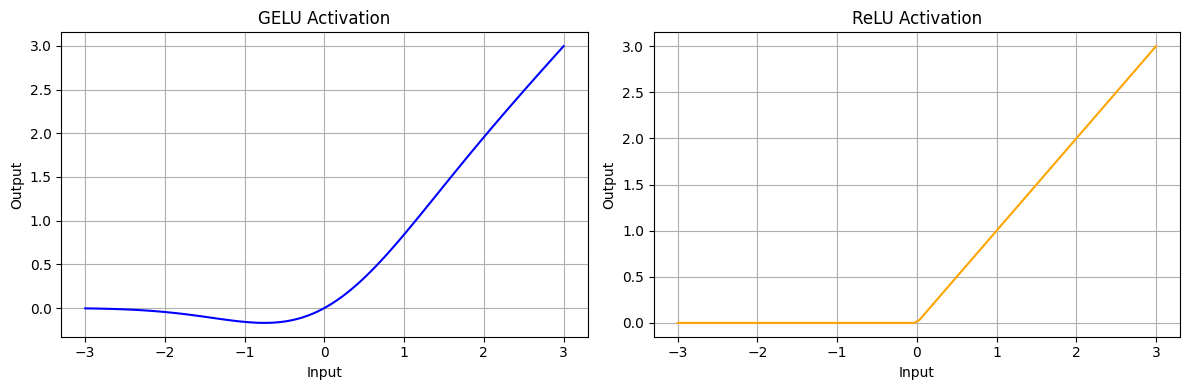

In [62]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Define activation functions
gelu = nn.GELU()
relu = nn.ReLU()

x = torch.linspace(-3, 3, 100)

y_gelu = gelu(x)
y_relu = relu(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# GELU plot
axes[0].plot(x, y_gelu, color='blue')
axes[0].set_title('GELU Activation')
axes[0].set_xlabel('Input')
axes[0].set_ylabel('Output')
axes[0].grid(True)

# ReLU plot
axes[1].plot(x, y_relu, color='orange')
axes[1].set_title('ReLU Activation')
axes[1].set_xlabel('Input')
axes[1].set_ylabel('Output')
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [63]:
Config_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias

}

cfg = Config_124M

In [64]:
class feedforward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]),#Expansion
            GELU(),#Expansion
            nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]) #Contraction
        )
    def forward(self ,x):
        return self.layers(x)

In [65]:
print(Config_124M["emb_dim"])

768


In [66]:
#Feed forward module me smalll neural network consisting of two linear
#layers and GELU activation layer
#using GELU function to implement smalll neural network module

ffn = feedforward(Config_124M)
x = torch.rand(2,3,768)
out = ffn(x)
print(out.shape)
#This helps bring the uniformity in the d_in and d_out

 

torch.Size([2, 3, 768])


In [67]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


In [68]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123) # specify random seed for the initial weights for reproducibility
model_without_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=False
)

In [69]:
def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [70]:
print(model_without_shortcut,sample_input)

ExampleDeepNeuralNetwork(
  (layers): ModuleList(
    (0-3): 4 x Sequential(
      (0): Linear(in_features=3, out_features=3, bias=True)
      (1): GELU()
    )
    (4): Sequential(
      (0): Linear(in_features=3, out_features=1, bias=True)
      (1): GELU()
    )
  )
) tensor([[ 1.,  0., -1.]])


In [71]:
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_without_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472


In [72]:
#Now we will do implementation of Transformer Block

In [73]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = feedforward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

In [74]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768) #A
block = TransformerBlock(Config_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)


# The preservation of shape throughout the transformer block architecture is not incidental
# but a crucial aspect of its design. 

# This design enables its effective application across a wide
# range of sequence-to-sequence tasks, where each output vector directly corresponds to an
# input vector, maintaining a one-to-one relationship. 

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


In [75]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [76]:
import torch
import torch.nn as nn

cfg = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

model = GPTModel(cfg)    # ← this creates your model object


In [77]:
torch.manual_seed(123)
model = GPTModel(Config_124M)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.1381,  0.0077, -0.1963,  ..., -0.0222, -0.1060,  0.1717],
         [ 0.3865, -0.8408, -0.6564,  ..., -0.5163,  0.2369, -0.3357],
         [ 0.6989, -0.1829, -0.1631,  ...,  0.1472, -0.6504, -0.0056],
         [-0.4290,  0.1669, -0.1258,  ...,  1.1579,  0.5303, -0.5549]],

        [[ 0.1094, -0.2894, -0.1467,  ..., -0.0557,  0.2911, -0.2824],
         [ 0.0882, -0.3552, -0.3527,  ...,  1.2930,  0.0053,  0.1898],
         [ 0.6091,  0.4702, -0.4094,  ...,  0.7688,  0.3787, -0.1974],
         [-0.0612, -0.0737,  0.4751,  ...,  1.2463, -0.3834,  0.0609]]],
       grad_fn=<UnsafeViewBackward0>)


In [78]:
torch.manual_seed(123)
model = GPTModel(Config_124M)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.1381,  0.0077, -0.1963,  ..., -0.0222, -0.1060,  0.1717],
         [ 0.3865, -0.8408, -0.6564,  ..., -0.5163,  0.2369, -0.3357],
         [ 0.6989, -0.1829, -0.1631,  ...,  0.1472, -0.6504, -0.0056],
         [-0.4290,  0.1669, -0.1258,  ...,  1.1579,  0.5303, -0.5549]],

        [[ 0.1094, -0.2894, -0.1467,  ..., -0.0557,  0.2911, -0.2824],
         [ 0.0882, -0.3552, -0.3527,  ...,  1.2930,  0.0053,  0.1898],
         [ 0.6091,  0.4702, -0.4094,  ...,  0.7688,  0.3787, -0.1974],
         [-0.0612, -0.0737,  0.4751,  ...,  1.2463, -0.3834,  0.0609]]],
       grad_fn=<UnsafeViewBackward0>)


In [79]:
model = GPTModel(cfg)

print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [80]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [81]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters weight tying: {total_params_gpt2:,}")

Number of trainable parameters weight tying: 124,412,160


In [82]:
total_size = total_params*4 #A
total_size_mb = total_size / (1024*1024) #B
print("total size: ",total_size_mb) 

total size:  621.83203125


In [83]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): feedforward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feature

In [84]:
def generate_text_simple(model, idx, max_new_tokens,context_size):
    #idx(batch, n_tokens)

#     Input batch:
#  tensor([[6109, 3626, 6100,  345],
#         [6109, 1110, 6622,  257]])
    for _ in range(max_new_tokens):
        #Crop current context agr context size bda hogya to
        #if LLM supports only 5 tokens and context size is 10
        #last 5 tokens or words are used as context

        idx_cond = idx[:,-context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits =logits[:,-1,:]

        probab=torch.softmax(logits,dim = -1)
        idx_next = torch.argmax(probab, dim =-1,keepdim = True) #which is (batch, 1)

        #Appending the sampled index in seq
        idx= torch.cat((idx,idx_next),dim=1) #which is (batch,n_tokens+1)
    return idx

In [85]:
start_context ="Hello, Crush for LLM's"
encoded = tokenizer.encode(start_context)
print("encoded",encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:",encoded_tensor.shape)

encoded [15496, 11, 40104, 329, 27140, 44, 338]
encoded_tensor.shape: torch.Size([1, 7])


In [86]:
model.eval()
out =generate_text_simple(
    model =model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size = Config_124M["context_length"]

)
print("Output: ",out)
print("Output length: ",len(out[0]))

Output:  tensor([[15496,    11, 40104,   329, 27140,    44,   338, 26490, 23457, 31182,
         39092,  6973, 49711]])
Output length:  13


In [87]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, Crush for LLM's employing paradigm Machines wearable controls delegated


In [88]:
#Now we will be finding the LOSS in order to give good prediction 
#unlikely Hello, Crush for LLM's employing paradigm Machines wearable controls delegated

Config_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False     
}

torch.manual_seed(123)
model = GPTModel(Config_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): feedforward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [89]:
#We reduce the context length (context_length) of only 256 tokens to reduce the computational resource requirements 
#for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens
import tiktoken


def text_to_token_ids(text,tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat =token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context,tokenizer),
    max_new_tokens = 10,
    context_size = Config_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


In [90]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [91]:
with torch.no_grad():
    logits = model(inputs)

probas =torch.softmax(logits,dim = -1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [92]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)
#dim = -1 depicts that the argmax is applied on the column

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [93]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [94]:
#Now we should be aware off that we will need to know that how much are we away from the correct prediction
#and thus Cros entropy helps us do this

text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)


Text 1: tensor([    0.0001,     0.0000,     0.0000])
Text 2: tensor([    0.0000,     0.0001,     0.0000])


In [95]:
# Compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [96]:
# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


In [97]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


In [98]:
# PyTorch already implements a cross_entropy function that carries out the previous steps
# Before we apply the cross_entropy function, let's check the shape of the logits and targets

# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])
Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [99]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


In [100]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


In [104]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://github.com/rasbt/LLMs-from-scratch/blob/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w",encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path,"r",encoding="utf-8") as file:
        text_data = file.read()

In [106]:
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [108]:
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [110]:
total_characters =len(text_data)
total_tokens =len(tokenizer.encode(text_data))
print(total_characters)

20479


In [111]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256, 
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [132]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

In [133]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [134]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

In [135]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

print(len(train_loader))
print(len(val_loader))


Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])
9
1


In [136]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


In [137]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): feedforward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [138]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [139]:
import torch

torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    model.to(device)
except RuntimeError as e:
    print("CUDA out of memory, switching to CPU...")
    device = torch.device("cpu")
    model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)


CUDA out of memory, switching to CPU...
Training loss: 10.98758347829183
Validation loss: 10.981106758117676
